# **3.2 Implementing Linear Regression from Scratch**
In this section, we will **implement the entire method from scratch, including the data pipeline, the model, the loss function, and the mini-batch stochastic gradient descent optimizer.** Although modern deep learning frameworks can automate nearly all of this work, implementing it from scratch ensures that we truly understand what we are doing. At the same time, a deeper understanding of how it works will make it easier for us to customize models, layers, or loss functions. In this section, we will use only tensors and automatic differentiation.

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

## **3.2.1 Generate a Dataset**
For simplicity, we will construct a synthetic dataset based on a linear model with noise. Our task is to recover the parameters of this model using this limited-sample dataset. We will use low-dimensional data so that it can be easily visualized. In the code below, we generate a dataset containing 1,000 samples, each of which consists of two features sampled from a standard normal distribution. Our synthetic dataset is a matrix $X \in \mathbb{R}^{1000x2}$.<br><br>
We generate the dataset and its labels using the linear model parameters $w = [2, −3.4]^T, b = 4.2$, and the noise term $\epsilon$:
##### **(3.2.1)**
$$y=Xw+b+\epsilon$$
$\epsilon$ can be regarded as the potential observation error when the model makes predictions and assigns labels. Here, we assume that the standard assumption holds, namely, that $\epsilon$ follows a normal distribution with a mean of 0. To simplify the problem, we set the standard deviation to 0.01.

In [2]:
def synthetic_data(w, b, num_examples): #@save
    """Generate y = Xw + b + noise"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [3]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

Note that each row in `features` contains a two-dimensional data sample, and each row in `labels` contains a one-dimensional label value (a scalar).

In [4]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([0.5941, 2.2101]) 
label: tensor([-2.1178])


By plotting a scatter plot of the second feature, `features[:, 1]`, and the labels, we can visually observe the linear relationship between them.

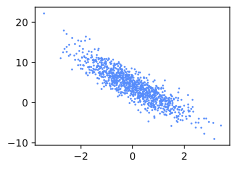

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

## **3.2.2 Read the dataset**
**When training a model, we need to iterate through the dataset, drawing a small batch of samples at a time and using them to update our model.** Since this process is fundamental to training machine learning algorithms, it is necessary to define a function that shuffles the samples in the dataset and retrieves them in small batches.<br><br>
In the code below, we define a `data_iter` function that takes a batch size, a feature matrix, and a label vector as inputs and generates mini-batches of size `batch_size`. Each mini-batch contains a set of features and labels.

In [6]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # These samples were selected at random, with no specific order.
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

Typically, we leverage the parallel computing capabilities of GPUs to process “small batches” of a reasonable size. Model computations for each sample can be performed in parallel, and the gradients of the loss function for each sample can also be computed in parallel.<br><br>
The feature dimension of each batch displays the batch size and the number of input features. Similarly, the label shape of the batch is equal to `batch_size`.

In [7]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.8032e+00,  3.5086e-01],
        [-1.0956e+00, -4.2442e-02],
        [-7.7016e-04, -1.7259e+00],
        [-1.2206e+00,  8.3029e-01],
        [-3.4833e-01,  1.6088e-02],
        [ 2.6413e-01, -2.3627e-01],
        [-7.2977e-01, -2.5752e-01],
        [-5.8442e-01, -9.2584e-01],
        [-1.0030e+00,  2.2101e-01],
        [-3.1107e-01,  1.0296e-01]]) 
 tensor([[-0.5817],
        [ 2.1301],
        [10.0882],
        [-1.0594],
        [ 3.4574],
        [ 5.5202],
        [ 3.6111],
        [ 6.1734],
        [ 1.4659],
        [ 3.2280]])


## **3.2.3 Initialize Model Parameters**
In the code below, we initialize the weights by sampling random numbers from a normal distribution with a mean of 0 and a standard deviation of 0.01, and we initialize the bias to 0.

In [8]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

After initializing the parameters, **our task is to update them until they adequately fit our data. Each update requires calculating the gradient of the loss function with respect to the model parameters. With this gradient, we can update each parameter in the direction that minimizes the loss.**

## **3.2.4 Define the Model**
Next, we must define the model by associating its inputs and parameters with its output. Recall that to compute the output of a linear model, we simply perform the matrix-vector multiplication of the input features $X$ and the model weights $w$, and then add the bias $b$. Note that $Xw$ above is a vector, while $b$ is a scalar. Recall the broadcasting mechanism described in Section [2.1.3](../../chapter_preliminaries/content/data_manipulation.ipynb#213): when we add a scalar to a vector, the scalar is added to each component of the vector.

In [9]:
def linreg(X, w, b): #@save
    """Linear Regression Model"""
    return torch.matmul(X, w) + b

## **3.2.5 Define the loss function**
Since we need to compute the gradient of the loss function, we should first define the loss function. **In the implementation, we need to transform the shape of the true values y so that it matches the shape of the predicted values y_hat.**

In [12]:
def square_loss(y_hat, y): #@save
    """Squared Loss Function"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

## **3.2.6 Define the optimization algorithm**
Although linear regression has an analytical solution, the other models in this book do not.<br><br>
In each step, we use a small batch randomly sampled from the dataset and then compute the gradient of the loss based on the parameters. Next, we update our parameters in the direction that minimizes the loss. The following function implements mini-batch stochastic gradient descent updates. The function accepts the set of model parameters, the learning rate, and the batch size as inputs. The magnitude of each update is determined by the learning rate lr. Since the loss we compute is the sum over a batch of samples, we use the batch size to normalize the step size so that the step size does not depend on our choice of batch size.

In [13]:
def sgd(params, lr, batch_size): #@save
    """Small-Batch Stochastic Gradient Descent"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## **3.2.7 Training**
In each iteration, we read a small batch of training samples and pass them through our model to obtain a set of predictions. After calculating the loss, we perform backpropagation and store the gradients for each parameter. Finally, we call the SGD optimization algorithm to update the model parameters.<br><br>
To summarize, we will execute the following loop:<br>
* Initialize Parameters
* Repeat the following exercise until you're done
  * Compute the gradient $$g \leftarrow \partial_{w,b}\frac{1}{|\mathcal{B}|}\sum_{i \in \mathcal{B}}l(x^{(i)},y^{(i)},w,b)$$
  * Update Parameters $$(w, b) \leftarrow (w, b) - \eta g$$

In each epoch, we use the `data_iter` function to iterate through the entire dataset and process all samples in the training set once (assuming the number of samples is divisible by the batch size). The number of epochs, `num_epochs`, and the learning rate, `lr`, are both hyperparameters, set to 3 and 0.03, respectively. Setting hyperparameters is tricky and requires adjustment through trial and error.

In [14]:
lr = 0.03
num_epochs = 3
net = linreg
loss = square_loss

In [15]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # Small-batch losses for X and y
        # Because the shape of `l` is `(batch_size, 1)`, not a scalar. All elements in `l` are added together
        l.sum().backward()
        sgd([w, b], lr, batch_size) # Update Parameters Using the Gradient of the Parameters
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.033019
epoch 2, loss 0.000116
epoch 3, loss 0.000046


In fact, the true parameters and the parameters learned through training are indeed very close.

In [17]:
print(f'Estimation Error of w: {true_w- w.reshape(true_w.shape)}')
print(f'Estimation Error of b: {true_b- b}')

Estimation Error of w: tensor([ 1.9825e-04, -9.5606e-05], grad_fn=<SubBackward0>)
Estimation Error of b: tensor([-2.9087e-05], grad_fn=<RsubBackward1>)


## **Summarize**
* We learned how deep neural networks are implemented and optimized. In this process, we used only tensors and automatic differentiation; there was no need to define layers or complex optimizers.
* In the following sections, we will describe other models based on the concepts we just introduced and learn how to implement them more concisely.